In [71]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mis_dro.likelihood import cholesky_param_to_covariance
from mis_dro.bayes_conjugates import *
from mis_dro.dataset import portfolio_dataset

In [72]:
dgp = "DowJones"
replication = 0

mmc2_dir = Path("/dcs/pg20/u1508153/datasets/misdro/mmc2")
assert mmc2_dir.exists()
# returns_df = pd.read_excel(mmc2_dir / "Datasets" / dgp / f"{dgp}.xlsx", sheet_name="Assets_Returns", header=None)
data, data_eval = portfolio_dataset(dgp, replication, mmc2_dir)

portfolio_npl_samples_csv = Path(f"/dcs/large/u1508153/misdro/mmd_portfolio/portfolio_theta_sample_{dgp}_{replication}.csv")
npl_df = pd.read_csv(portfolio_npl_samples_csv, index_col=False, header=None)
npl_samples = npl_df.values

num_posterior_samples = npl_samples.shape[0]
dim = data.shape[1]

In [73]:
# Bayes posterior
posterior = "normal_inverse_wishart"
theta_prior = default_prior_params(posterior, dim=dim)
theta_posterior = get_posterior_params(posterior, data, theta_prior)
mu_post, _, iota_post, Psi_post = theta_posterior

In [74]:
# NPL posterior with full covariance
npl_means = np.zeros((num_posterior_samples, dim))
npl_covs = np.zeros((num_posterior_samples, dim, dim))
for i in range(num_posterior_samples):
    npl_means[i] = npl_samples[i,:dim]
    npl_covs[i] = cholesky_param_to_covariance(dim, npl_samples[i,dim:])

In [75]:
mean_npl_mean = npl_means.mean(axis=0)
mean_npl_cov = npl_covs.mean(axis=0)

In [76]:
mean_npl_mean - mu_post

array([ 0.00850804,  0.00888279, -0.00061311,  0.00636964,  0.00434625,
        0.00702794,  0.00127299, -0.0012346 ,  0.00700781,  0.00544269,
        0.00422191,  0.00106234,  0.01310236,  0.00395228,  0.0033055 ,
        0.00283002,  0.00738301,  0.00622115,  0.02221605,  0.00319956,
        0.00217758,  0.01300178,  0.00576759,  0.00118292,  0.00259142,
        0.00027321,  0.00242982,  0.0006584 ])

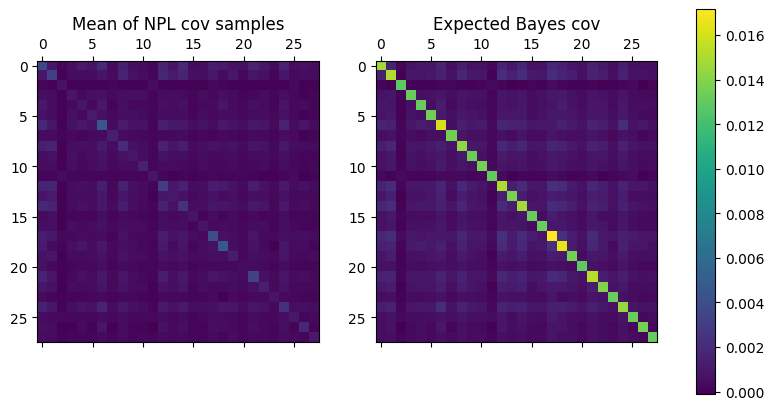

In [77]:
# Create a figure and axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

bayes_cov = (1.0 / float(iota_post)) * Psi_post
vmin = np.min([bayes_cov, mean_npl_cov])
vmax = np.max([bayes_cov, mean_npl_cov])

# Plot the first matrix
c1 = ax1.matshow(mean_npl_cov, cmap='viridis', vmin=vmin, vmax=vmax)
ax1.set_title('Mean of NPL cov samples')

# Plot the second matrix
c2 = ax2.matshow(bayes_cov, cmap='viridis', vmin=vmin, vmax=vmax)
ax2.set_title('Expected Bayes cov')

# Create a shared colorbar
cbar = fig.colorbar(c1, ax=[ax1, ax2], orientation='vertical')

fig.show()
